<!-- Cell purpose: Introduce the UVC embryonated egg analysis notebook. -->

# UVC Embryonated Egg Analysis (`analysis_UVC_embryonated.ipynb`)

This notebook analyzes embryonated eggs for UVC treatment groups and pooled controls.

Rules applied:
- Main readout: `dt_motion_stop_h = t_motion_stop_h - t_start_h`
- Still moving at end-of-footage: `t_motion_stop_h = NA` and `death_mode = NA`
- Exclude from all analyses: `flags` contains `no_larvae`
- In-egg stop cohort: exclude `death_after_hatch`
- Max observation time: 700 h


In [24]:
# Define the requested UVC treatment groups

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
except Exception as exc:
    KaplanMeierFitter = None
    logrank_test = None
    multivariate_logrank_test = None
    print(f"lifelines import failed: {exc}. Step 8 / 9C requires `pip install lifelines`.")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/02_master_embryonated.csv"

TREATMENT_GROUP_ORDER = [
    "UVC-6W-600s",
    "UVC-6W-300s",
    "UVC-6W-180s",
    "UVC-6W-120s",
    "UVC-6W-60s",
    "UVC-6W-30s",
]

GROUP_TO_LABELS = {
    "UVC-6W-600s": ["UVC-6W-600s", "UVC-6W-600"],
    "UVC-6W-300s": ["UVC-6W-300s", "UVC-6W-300"],
    "UVC-6W-180s": ["UVC-6W-180s", "UVC-6W-180"],
    "UVC-6W-120s": ["UVC-6W-120s", "UVC-6W-120"],
    "UVC-6W-60s": ["UVC-6W-60s", "UVC-6W-60"],
    "UVC-6W-30s": ["UVC-6W-30s", "UVC-6W-30"],
}

CONTROL_LABELS = [
    "400-SHG-40mW-control",
    "800-control-330mW",
    "400-SHG-20mW-control",
]

GROUP_TO_LABELS = {
    "Control (pooled)": CONTROL_LABELS,
    **GROUP_TO_LABELS,
}

ALL_GROUP_ORDER = ["Control (pooled)", *TREATMENT_GROUP_ORDER]
DEATH_MODES = ["apoptotic_like", "necrotic_like", "uncertain"]
DEATH_MODE_DISPLAY = {
    "apoptotic_like": "Vacuolated (apoptosis-like)",
    "necrotic_like": "Lytic (necrosis-like)",
    "uncertain": "Indeterminate/hatched",
    "uncertein": "Indeterminate/hatched",
}
TERMINAL_PHENOTYPE_LABEL = "Terminal phenotype"
DEATH_MODE_DISPLAY_ORDER = [DEATH_MODE_DISPLAY[m] for m in DEATH_MODES]
DEATH_MODE_PALETTE = {
    "Vacuolated (apoptosis-like)": "#59a14f",
    "Lytic (necrosis-like)": "#e15759",
    "Indeterminate/hatched": "#4e79a7",
}
MAX_FOOTAGE_H = 700.0

OUT_BASE = Path("254nm/embryonated")
PLOTS_DIR = OUT_BASE / "plots"
TABLES_DIR = OUT_BASE / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)



In [25]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "na", "none"}:
        return np.nan
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def normalize_flags(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    if raw == "" or raw.lower() in {"na", "none"}:
        return np.nan

    parts = [to_snake_or_nan(part) for part in raw.split(";")]
    parts = [p for p in parts if pd.notna(p)]
    if not parts:
        return np.nan
    return ";".join(parts)


def has_flag(series: pd.Series, token: str) -> pd.Series:
    token_norm = to_snake_or_nan(token)
    if pd.isna(token_norm):
        return pd.Series(False, index=series.index)
    pattern = rf"(?:^|;){re.escape(token_norm)}(?:$|;)"
    return series.fillna("").str.contains(pattern, regex=True)


def pct(n: int, d: int) -> float:
    return (100.0 * n / d) if d else np.nan


def median_iqr(series: pd.Series):
    vals = series.dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, np.nan
    return float(vals.median()), float(vals.quantile(0.25)), float(vals.quantile(0.75))


def p_to_sig(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


In [26]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

required_cols = [
    "egg_uid",
    "exp_label",
    "start_date",
    "control",
    "t_start_h",
    "t_motion_stop_h",
    "death_mode",
    "flags",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "death_mode"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

if "death_mode" in df.columns:
    df["death_mode"] = df["death_mode"].replace({"uncertein": "uncertain"})

if "flags" in df.columns:
    df["flags"] = df["flags"].map(normalize_flags)

df["exp_label_norm"] = df["exp_label"].map(to_snake_or_nan)

for col in [
    "control",
    "wl_nm",
    "power_mW",
    "irradiance_mW_cm2",
    "exposure_s",
    "fluence_J_cm2",
    "t_start_h",
    "t_motion_stop_h",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["dt_motion_stop_h"] = df["t_motion_stop_h"] - df["t_start_h"]

group_frames = []
for group_name, labels in GROUP_TO_LABELS.items():
    label_norm = {to_snake_or_nan(x) for x in labels}
    mask = df["exp_label_norm"].isin(label_norm)
    if group_name == "Control (pooled)":
        mask &= (df["control"] == 1)

    g = df.loc[mask].copy()
    g["analysis_group"] = group_name
    group_frames.append(g)

analysis_df = pd.concat(group_frames, ignore_index=True)
analysis_df["analysis_group"] = pd.Categorical(
    analysis_df["analysis_group"], categories=ALL_GROUP_ORDER, ordered=True
)

analysis_df["flag_no_larvae"] = has_flag(analysis_df["flags"], "no_larvae")
analysis_df["flag_death_after_hatch"] = has_flag(analysis_df["flags"], "death_after_hatch")
analysis_df["flag_exit_egg"] = has_flag(analysis_df["flags"], "exit_egg")
analysis_df["flag_terminal_twitching"] = has_flag(analysis_df["flags"], "terminal_twitching")

analysis_df["is_analyzed"] = ~analysis_df["flag_no_larvae"]
analysis_df["is_continued_motion"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].isna()
    & analysis_df["death_mode"].isna()
)
analysis_df["is_stopped_in_egg"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].notna()
    & (~analysis_df["flag_death_after_hatch"])
    & (analysis_df["t_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["is_event_survival"] = (
    analysis_df["is_analyzed"]
    & analysis_df["dt_motion_stop_h"].notna()
    & (analysis_df["dt_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["duration_survival_h"] = np.where(
    analysis_df["is_event_survival"], analysis_df["dt_motion_stop_h"], MAX_FOOTAGE_H
)
analysis_df["duration_survival_h"] = analysis_df["duration_survival_h"].astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

print(f"Loaded: {csv_file}")
print(f"Rows in full master table: {len(df)}")
print(f"Rows in analysis subset (control + UVC groups): {len(analysis_df)}")

group_counts_raw = (
    analysis_df.groupby("analysis_group", observed=False)
    .size()
    .rename("n_raw")
    .reset_index()
)

group_counts_analyzed = (
    analysis_df[analysis_df["is_analyzed"]]
    .groupby("analysis_group", observed=False)
    .size()
    .rename("n_after_no_larvae_exclusion")
    .reset_index()
)

counts_view = group_counts_raw.merge(group_counts_analyzed, on="analysis_group", how="left")
counts_view["n_after_no_larvae_exclusion"] = counts_view["n_after_no_larvae_exclusion"].fillna(0).astype(int)
display(counts_view)

missing_treatments = counts_view.loc[
    counts_view["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & (counts_view["n_raw"] == 0),
    "analysis_group",
].astype(str).tolist()
if missing_treatments:
    print("Note: Requested treatment labels with no rows in this master table:", ", ".join(missing_treatments))


analysis_preview_df = analysis_df[
    [
        "egg_uid",
        "analysis_group",
        "exp_label",
        "t_start_h",
        "t_motion_stop_h",
        "dt_motion_stop_h",
        "death_mode",
        "flags",
        "is_analyzed",
    ]
].copy()
analysis_preview_df[TERMINAL_PHENOTYPE_LABEL] = (
    analysis_preview_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(analysis_preview_df["death_mode"])
)
display(analysis_preview_df.drop(columns=["death_mode"]).head())


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/02_master_embryonated.csv
Rows in full master table: 811
Rows in analysis subset (control + UVC groups): 318


,analysis_group,n_raw,n_after_no_larvae_exclusion
0,Control (pooled),97,97
1,UVC-6W-600s,39,39
2,UVC-6W-300s,35,35
3,UVC-6W-180s,36,36
4,UVC-6W-120s,36,36
5,UVC-6W-60s,36,36
6,UVC-6W-30s,39,39


,egg_uid,analysis_group,exp_label,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,is_analyzed,Terminal phenotype
0,115,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
1,116,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
2,117,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
3,118,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
4,119,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN


In [27]:
# Data QC and overview table

qc_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[analysis_df["analysis_group"] == group].copy()
    sub_an = sub.loc[sub["is_analyzed"]].copy()

    n_total = int(len(sub))
    n_excl_no_larvae = int(sub["flag_no_larvae"].sum())
    n_analyzed = int(len(sub_an))

    row = {
        "group": group,
        "n_total": n_total,
        "n_excluded_no_larvae": n_excl_no_larvae,
        "pct_excluded_no_larvae": round(pct(n_excl_no_larvae, n_total), 1),
        "n_analyzed": n_analyzed,
    }

    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        row[f"n_{mode}"] = n_mode
        row[f"pct_{mode}"] = round(pct(n_mode, n_analyzed), 1)

    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        row[f"n_flag_{flag}"] = n_flag
        row[f"pct_flag_{flag}"] = round(pct(n_flag, n_analyzed), 1)

    qc_rows.append(row)

qc_overview_df = pd.DataFrame(qc_rows)
qc_overview_display_df = qc_overview_df.rename(
    columns={
        **{f"n_{mode}": f"n_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
        **{f"pct_{mode}": f"pct_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
    }
)
display(qc_overview_display_df)

qc_death_mode_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        qc_death_mode_long.append(
            {
                "group": group,
                "death_mode": mode,
                "n": n_mode,
                "pct": round(pct(n_mode, n_analyzed), 1),
            }
        )
qc_death_mode_long_df = pd.DataFrame(qc_death_mode_long)
qc_death_mode_long_df["death_mode"] = (
    qc_death_mode_long_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(qc_death_mode_long_df["death_mode"])
)
qc_death_mode_long_df = qc_death_mode_long_df.rename(columns={"death_mode": TERMINAL_PHENOTYPE_LABEL})
display(qc_death_mode_long_df)

qc_flags_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        qc_flags_long.append(
            {
                "group": group,
                "flag": flag,
                "n": n_flag,
                "pct": round(pct(n_flag, n_analyzed), 1),
            }
        )
qc_flags_long_df = pd.DataFrame(qc_flags_long)
display(qc_flags_long_df)

qc_overview_display_df.to_csv(TABLES_DIR / "uvc_embryonated_qc_overview.csv", index=False)
qc_death_mode_long_df.to_csv(TABLES_DIR / "uvc_embryonated_qc_death_mode_long.csv", index=False)
qc_flags_long_df.to_csv(TABLES_DIR / "uvc_embryonated_qc_flags_long.csv", index=False)

print(f"Saved QC tables to: {TABLES_DIR.resolve()}")


,group,n_total,n_excluded_no_larvae,pct_excluded_no_larvae,n_analyzed,n_Vacuolated (apoptosis-like),pct_Vacuolated (apoptosis-like),n_Lytic (necrosis-like),pct_Lytic (necrosis-like),n_Indeterminate/hatched,pct_Indeterminate/hatched,n_flag_death_after_hatch,pct_flag_death_after_hatch,n_flag_exit_egg,pct_flag_exit_egg,n_flag_terminal_twitching,pct_flag_terminal_twitching
0,Control (pooled),97,0,0.0,97,0,0.0,3,3.1,12,12.4,9,9.3,1,1.0,0,0.0
1,UVC-6W-600s,39,0,0.0,39,0,0.0,39,100.0,0,0.0,0,0.0,12,30.8,2,5.1
2,UVC-6W-300s,35,0,0.0,35,0,0.0,35,100.0,0,0.0,0,0.0,0,0.0,35,100.0
3,UVC-6W-180s,36,0,0.0,36,0,0.0,35,97.2,1,2.8,1,2.8,9,25.0,34,94.4
4,UVC-6W-120s,36,0,0.0,36,0,0.0,36,100.0,0,0.0,0,0.0,0,0.0,0,0.0
5,UVC-6W-60s,36,0,0.0,36,0,0.0,33,91.7,1,2.8,1,2.8,1,2.8,0,0.0
6,UVC-6W-30s,39,0,0.0,39,0,0.0,37,94.9,2,5.1,2,5.1,2,5.1,0,0.0


,group,Terminal phenotype,n,pct
0,Control (pooled),Vacuolated (apoptosis-like),0,0.0
1,Control (pooled),Lytic (necrosis-like),3,3.1
2,Control (pooled),Indeterminate/hatched,12,12.4
3,UVC-6W-600s,Vacuolated (apoptosis-like),0,0.0
4,UVC-6W-600s,Lytic (necrosis-like),39,100.0
5,UVC-6W-600s,Indeterminate/hatched,0,0.0
6,UVC-6W-300s,Vacuolated (apoptosis-like),0,0.0
7,UVC-6W-300s,Lytic (necrosis-like),35,100.0
8,UVC-6W-300s,Indeterminate/hatched,0,0.0
9,UVC-6W-180s,Vacuolated (apoptosis-like),0,0.0


,group,flag,n,pct
0,Control (pooled),death_after_hatch,9,9.3
1,Control (pooled),exit_egg,1,1.0
2,Control (pooled),terminal_twitching,0,0.0
3,UVC-6W-600s,death_after_hatch,0,0.0
4,UVC-6W-600s,exit_egg,12,30.8
5,UVC-6W-600s,terminal_twitching,2,5.1
6,UVC-6W-300s,death_after_hatch,0,0.0
7,UVC-6W-300s,exit_egg,0,0.0
8,UVC-6W-300s,terminal_twitching,35,100.0
9,UVC-6W-180s,death_after_hatch,1,2.8


Saved QC tables to: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/tables


In [28]:
# Motion cessation analysis (each UVC treatment separately)

motion_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()

    n_total = int(len(sub))
    n_cont = int(sub["is_continued_motion"].sum())

    sub_stopped_in_egg = sub.loc[
        sub["is_stopped_in_egg"] & sub["dt_motion_stop_h"].notna(),
        "dt_motion_stop_h",
    ]
    n_stop_in_egg = int(len(sub_stopped_in_egg))
    med, q1, q3 = median_iqr(sub_stopped_in_egg)

    motion_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_continued_motion": n_cont,
            "pct_continued_motion": round(pct(n_cont, n_total), 1),
            "n_stopped_in_egg": n_stop_in_egg,
            "pct_stopped_in_egg": round(pct(n_stop_in_egg, n_total), 1),
            "median_dt_motion_stop_h": round(med, 2) if pd.notna(med) else np.nan,
            "q1_dt_motion_stop_h": round(q1, 2) if pd.notna(q1) else np.nan,
            "q3_dt_motion_stop_h": round(q3, 2) if pd.notna(q3) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1:.2f} to {q3:.2f}" if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
        }
    )

motion_summary_df = pd.DataFrame(motion_rows)
display(motion_summary_df)
motion_summary_df.to_csv(TABLES_DIR / "uvc_embryonated_motion_cessation_summary.csv", index=False)


,treatment,n_total_excluding_no_larvae,n_continued_motion,pct_continued_motion,n_stopped_in_egg,pct_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,UVC-6W-600s,39,0,0.0,39,100.0,0.0,0.00,0.0,0.00 to 0.00
1,UVC-6W-300s,35,0,0.0,35,100.0,95.5,71.50,114.0,71.50 to 114.00
2,UVC-6W-180s,36,0,0.0,35,97.2,147.8,128.80,169.8,128.80 to 169.80
3,UVC-6W-120s,36,0,0.0,36,100.0,169.9,137.15,199.9,137.15 to 199.90
4,UVC-6W-60s,36,2,5.6,33,91.7,268.5,239.50,293.5,239.50 to 293.50
5,UVC-6W-30s,39,0,0.0,37,94.9,283.5,221.50,329.5,221.50 to 329.50


In [29]:
# Comparison table: percentage still moving at 700h

comparison_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_still = int(sub["is_continued_motion"].sum())
    comparison_rows.append(
        {
            "Treatment": group,
            "n_total": n_total,
            "n_still_moving": n_still,
            "% still moving": round(pct(n_still, n_total), 1),
        }
    )

still_moving_df = pd.DataFrame(comparison_rows)
display(still_moving_df)
still_moving_df.to_csv(TABLES_DIR / "uvc_embryonated_still_moving_comparison.csv", index=False)


,Treatment,n_total,n_still_moving,% still moving
0,Control (pooled),97,82,84.5
1,UVC-6W-600s,39,0,0.0
2,UVC-6W-300s,35,0,0.0
3,UVC-6W-180s,36,0,0.0
4,UVC-6W-120s,36,0,0.0
5,UVC-6W-60s,36,2,5.6
6,UVC-6W-30s,39,0,0.0


Figure caption: Terminal phenotype composition across analyzed UVC embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report absolute counts as n/total analyzed for each treatment.


,treatment,n_total_analyzed,n,pct,Terminal phenotype
0,UVC-6W-600s,39,0,0.0,Vacuolated (apoptosis-like)
1,UVC-6W-600s,39,39,100.0,Lytic (necrosis-like)
2,UVC-6W-600s,39,0,0.0,Indeterminate/hatched
3,UVC-6W-300s,35,0,0.0,Vacuolated (apoptosis-like)
4,UVC-6W-300s,35,35,100.0,Lytic (necrosis-like)
5,UVC-6W-300s,35,0,0.0,Indeterminate/hatched
6,UVC-6W-180s,36,0,0.0,Vacuolated (apoptosis-like)
7,UVC-6W-180s,36,35,97.2,Lytic (necrosis-like)
8,UVC-6W-180s,36,1,2.8,Indeterminate/hatched
9,UVC-6W-120s,36,0,0.0,Vacuolated (apoptosis-like)


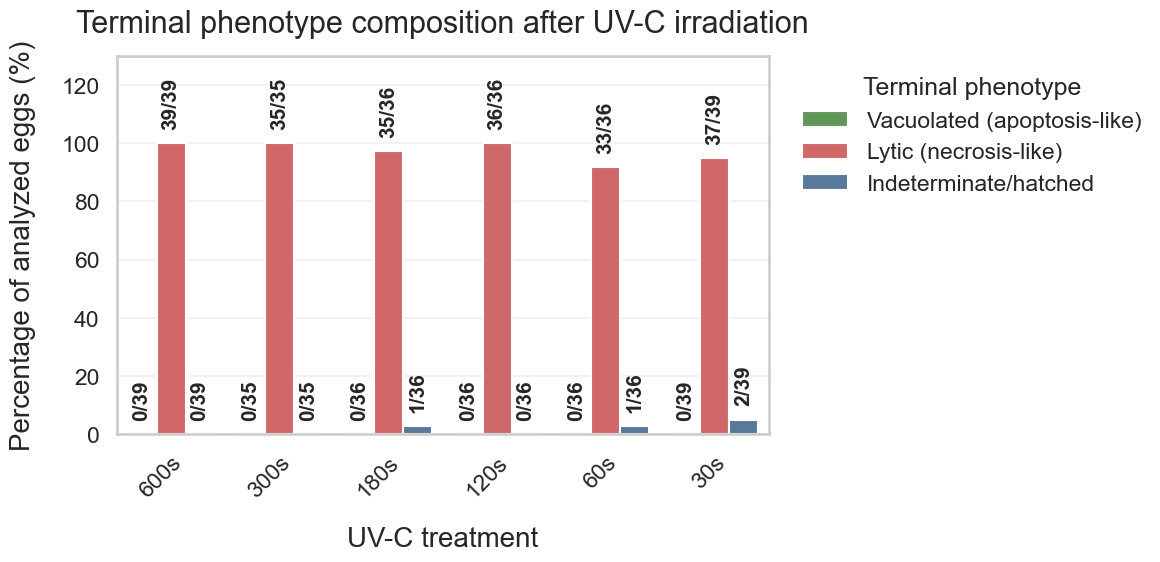

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_death_mode_distribution.png


In [30]:
# Terminal phenotype distribution (n, %) per treatment

print('Figure caption: Terminal phenotype composition across analyzed UVC embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report absolute counts as n/total analyzed for each treatment.')

death_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    for mode in DEATH_MODES:
        n_mode = int((sub["death_mode"] == mode).sum())
        death_rows.append(
            {
                "treatment": group,
                "death_mode": mode,
                "n_total_analyzed": n_total,
                "n": n_mode,
                "pct": round(pct(n_mode, n_total), 1),
            }
        )

death_mode_dist_df = pd.DataFrame(death_rows)
death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] = (
    death_mode_dist_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(death_mode_dist_df["death_mode"])
)
display(death_mode_dist_df.drop(columns=["death_mode"]))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=death_mode_dist_df,
    x="treatment",
    y="pct",
    hue=TERMINAL_PHENOTYPE_LABEL,
    hue_order=DEATH_MODE_DISPLAY_ORDER,
    order=TREATMENT_GROUP_ORDER,
    palette=DEATH_MODE_PALETTE,
    ax=ax,
)
ax.set_xlabel("UV-C treatment", labelpad=18, fontsize=20)
ax.set_ylabel("Percentage of analyzed eggs (%)", labelpad=18, fontsize=20)
ax.set_title("Terminal phenotype composition after UV-C irradiation", y=1.04, fontsize=22)
ymax = death_mode_dist_df["pct"].dropna().max() if len(death_mode_dist_df) else 100
ax.set_ylim(0, max(130, (float(ymax) + 10) if pd.notna(ymax) else 130))
ax.legend(title=TERMINAL_PHENOTYPE_LABEL, frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)
uvc_xlabels = [t.replace("UVC-6W-", "") for t in TREATMENT_GROUP_ORDER]
ax.set_xticks(range(len(TREATMENT_GROUP_ORDER)))
ax.set_xticklabels(uvc_xlabels, rotation=45, ha="right", rotation_mode="anchor")
for container, mode_label in zip(ax.containers, DEATH_MODE_DISPLAY_ORDER):
    labels = []
    for treatment in TREATMENT_GROUP_ORDER:
        row = death_mode_dist_df[
            (death_mode_dist_df["treatment"] == treatment)
            & (death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] == mode_label)
        ]
        if row.empty:
            labels.append("")
            continue
        n_total = int(row["n_total_analyzed"].iloc[0])
        n_mode = int(row["n"].iloc[0])
        labels.append(f"{n_mode}/{n_total}" if n_total > 0 else "")
    bar_texts = ax.bar_label(container, labels=labels, padding=10, fontsize=15, fontweight="bold", rotation=90)
    for txt in bar_texts:
        txt.set_clip_on(False)
plt.tight_layout()

out_png = PLOTS_DIR / "uvc_embryonated_death_mode_distribution.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png.resolve()}")

death_mode_dist_df.drop(columns=["death_mode"]).to_csv(TABLES_DIR / "uvc_embryonated_death_mode_distribution.csv", index=False)




Figure caption: Terminal twitching frequency across analyzed UVC treatment groups. Each bar reports `n_terminal_twitching / n_total_excluding_no_larvae * 100` for one treatment, so denominators are treatment-specific analyzed egg counts after no_larvae exclusion.


,treatment,n_total_excluding_no_larvae,n_terminal_twitching,pct_terminal_twitching
0,UVC-6W-600s,39,2,5.1
1,UVC-6W-300s,35,35,100.0
2,UVC-6W-180s,36,34,94.4
3,UVC-6W-120s,36,0,0.0
4,UVC-6W-60s,36,0,0.0
5,UVC-6W-30s,39,0,0.0


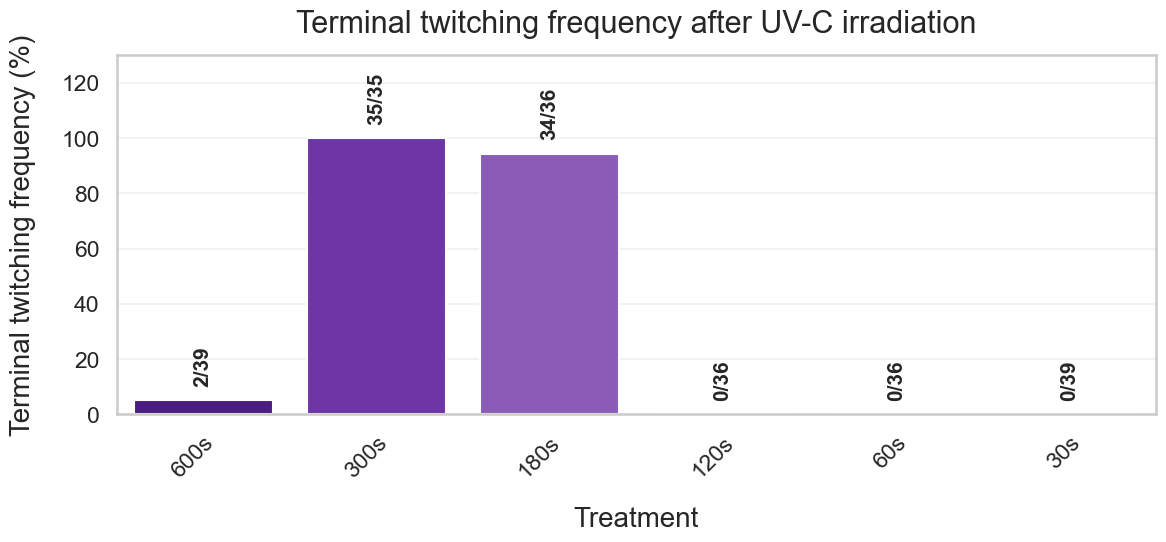

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_terminal_twitching_frequency.png


In [31]:
# Terminal twitching analysis (UVC-specific phenotype)

print('Figure caption: Terminal twitching frequency across analyzed UVC treatment groups. Each bar reports `n_terminal_twitching / n_total_excluding_no_larvae * 100` for one treatment, so denominators are treatment-specific analyzed egg counts after no_larvae exclusion.')

tt_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_tt = int(sub["flag_terminal_twitching"].sum())
    tt_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_terminal_twitching": n_tt,
            "pct_terminal_twitching": round(pct(n_tt, n_total), 1),
        }
    )

terminal_twitching_df = pd.DataFrame(tt_rows)
display(terminal_twitching_df)

fig, ax = plt.subplots(figsize=(12, 5.8))
uvc_treatment_colors = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
sns.barplot(
    data=terminal_twitching_df,
    x="treatment",
    y="pct_terminal_twitching",
    order=TREATMENT_GROUP_ORDER,
    color="#9a9a9a",
    errorbar=None,
    ax=ax,
)
for patch, treatment in zip(ax.patches, TREATMENT_GROUP_ORDER):
    patch.set_facecolor(uvc_treatment_colors[treatment])
ax.set_xlabel("Treatment", labelpad=18, fontsize=20)
ax.set_ylabel("Terminal twitching frequency (%)", labelpad=18, fontsize=20)
ax.set_title("Terminal twitching frequency after UV-C irradiation", y=1.04, fontsize=22)
ymax = terminal_twitching_df["pct_terminal_twitching"].dropna().max() if len(terminal_twitching_df) else 100
ax.set_ylim(0, max(130, (float(ymax) + 10) if pd.notna(ymax) else 130))
ax.grid(axis="y", alpha=0.25)
uvc_xlabels = [t.replace("UVC-6W-", "") for t in TREATMENT_GROUP_ORDER]
ax.set_xticks(range(len(TREATMENT_GROUP_ORDER)))
ax.set_xticklabels(uvc_xlabels, rotation=45, ha="right", rotation_mode="anchor")
bar_labels = [
    f"{int(row.n_terminal_twitching)}/{int(row.n_total_excluding_no_larvae)}"
    if int(row.n_total_excluding_no_larvae) > 0 else ""
    for row in terminal_twitching_df.itertuples(index=False)
]
for patch, label in zip(ax.patches, bar_labels):
    if not label:
        continue
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    ax.annotate(
        label,
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=15,
        fontweight="bold",
        clip_on=False,
    )
plt.tight_layout()

out_png = PLOTS_DIR / "uvc_embryonated_terminal_twitching_frequency.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

terminal_twitching_df.to_csv(TABLES_DIR / "uvc_embryonated_terminal_twitching_summary.csv", index=False)
print(f"Saved: {out_png.resolve()}")



In [32]:
# Death-after-hatch events per treatment

dah_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_dah = int(sub["flag_death_after_hatch"].sum())
    dah_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_death_after_hatch": n_dah,
            "pct_death_after_hatch": round(pct(n_dah, n_total), 1),
        }
    )

death_after_hatch_df = pd.DataFrame(dah_rows)
display(death_after_hatch_df)

death_after_hatch_df.to_csv(TABLES_DIR / "uvc_embryonated_death_after_hatch_summary.csv", index=False)


,treatment,n_total_excluding_no_larvae,n_death_after_hatch,pct_death_after_hatch
0,UVC-6W-600s,39,0,0.0
1,UVC-6W-300s,35,0,0.0
2,UVC-6W-180s,36,1,2.8
3,UVC-6W-120s,36,0,0.0
4,UVC-6W-60s,36,1,2.8
5,UVC-6W-30s,39,2,5.1


Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across UVC treatments retained for boxplot visualization. Only in-egg stop events are plotted; UVC-6W-600s is excluded due to near-baseline non-motility at footage start. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs.


,analysis_group,n_points
0,UVC-6W-600s,39
1,UVC-6W-300s,35
2,UVC-6W-180s,35
3,UVC-6W-120s,36
4,UVC-6W-60s,33
5,UVC-6W-30s,37


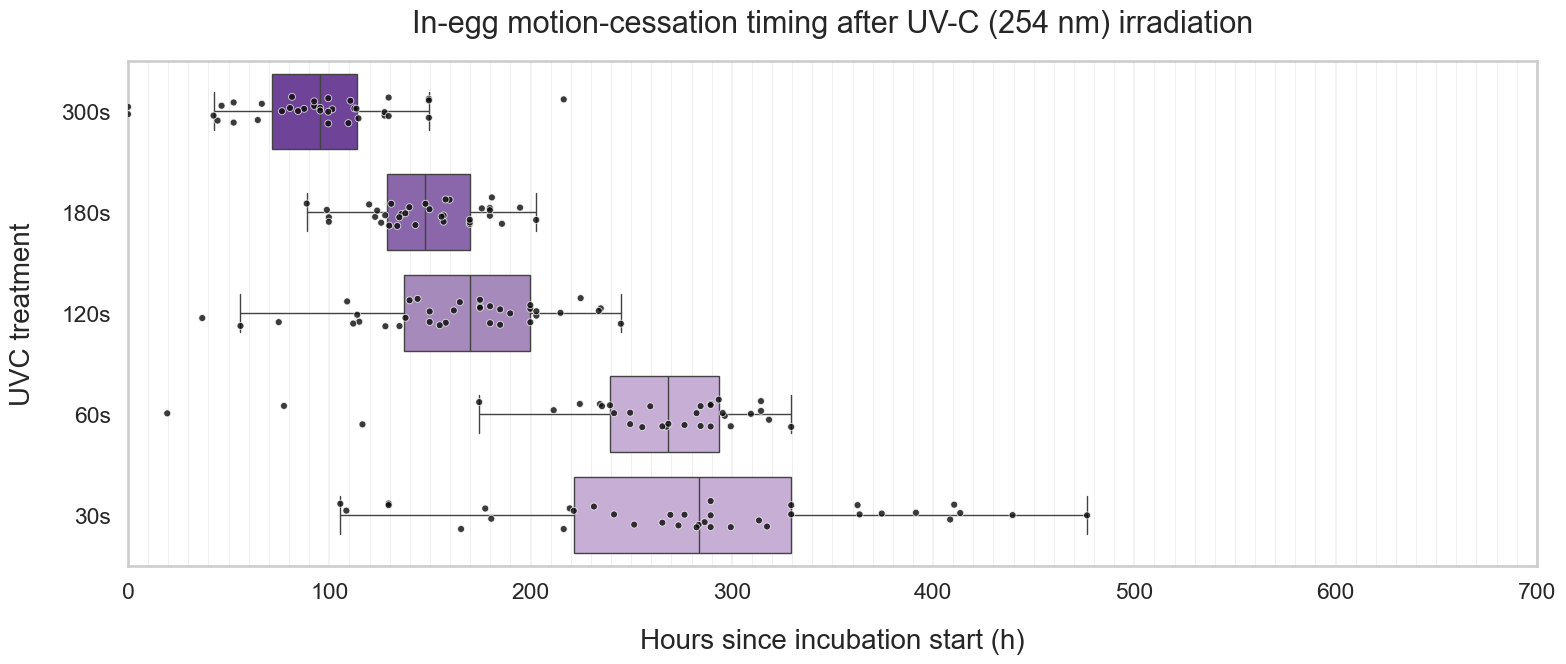

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_dt_motion_stop_boxplot.png
Note: `UVC-6W-600s` was removed from this boxplot because almost all eggs were already non-motile at the beginning of footage (dt_motion_stop_h <= 0 h: 37/39, 94.9%).


In [33]:
# Horizontal boxplot + stripplot overlay: in-egg motion stop times (UVC treatments only)

print('Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across UVC treatments retained for boxplot visualization. Only in-egg stop events are plotted; UVC-6W-600s is excluded due to near-baseline non-motility at footage start. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs.')

boxplot_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["egg_uid", "analysis_group", "dt_motion_stop_h", "flags", "death_mode"],
].copy()

point_counts = (
    boxplot_df.groupby("analysis_group", observed=False)
    .size()
    .reindex(TREATMENT_GROUP_ORDER, fill_value=0)
    .rename("n_points")
    .reset_index()
)
display(point_counts)

if len(boxplot_df) == 0:
    raise ValueError("No in-egg stop rows are available for UVC treatments.")

EXCLUDE_FROM_PLOT = {"UVC-6W-600s"}
groups_for_plot = [
    g for g in TREATMENT_GROUP_ORDER
    if (g not in EXCLUDE_FROM_PLOT)
    and int(point_counts.loc[point_counts["analysis_group"] == g, "n_points"].sum()) > 0
]

if not groups_for_plot:
    raise ValueError("No treatment remains for plotting after exclusion rules.")

plot_df = boxplot_df[boxplot_df["analysis_group"].isin(groups_for_plot)].copy()

uvc_treatment_colors = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
palette = {g: uvc_treatment_colors[g] for g in groups_for_plot}
point_palette = {g: "#0A0A0A" for g in groups_for_plot}

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    hue="analysis_group",
    order=groups_for_plot,
    hue_order=groups_for_plot,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    dodge=False,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    hue="analysis_group",
    order=groups_for_plot,
    hue_order=groups_for_plot,
    palette=point_palette,
    dodge=False,
    jitter=0.15,
    size=5,
    alpha=0.8,
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
)

ax.set_xlabel("Hours since incubation start (h)", labelpad=18, fontsize=20)
ax.set_ylabel("UVC treatment", labelpad=18, fontsize=20)
ax.set_title("In-egg motion-cessation timing after UV-C (254 nm) irradiation", y=1.04, fontsize=22)
uvc_ylabels = [g.replace("UVC-6W-", "") for g in groups_for_plot]
ax.set_yticks(range(len(groups_for_plot)))
ax.set_yticklabels(uvc_ylabels)
ax.set_xlim(0, MAX_FOOTAGE_H)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

plt.tight_layout()

out_png = PLOTS_DIR / "uvc_embryonated_dt_motion_stop_boxplot.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

plot_df.to_csv(TABLES_DIR / "uvc_embryonated_dt_motion_stop_boxplot_data.csv", index=False)
point_counts.to_csv(TABLES_DIR / "uvc_embryonated_dt_motion_stop_boxplot_counts.csv", index=False)
print(f"Saved: {out_png.resolve()}")

sub_600 = analysis_df.loc[
    (analysis_df["analysis_group"] == "UVC-6W-600s") & (analysis_df["is_analyzed"])
].copy()
n_total_600 = int(len(sub_600))
if n_total_600 > 0:
    n_non_motile_start_600 = int((sub_600["dt_motion_stop_h"].fillna(np.inf) <= 0).sum())
    pct_non_motile_start_600 = round(pct(n_non_motile_start_600, n_total_600), 1)
    print(
        "Note: `UVC-6W-600s` was removed from this boxplot because almost all eggs were already "
        "non-motile at the beginning of footage "
        f"(dt_motion_stop_h <= 0 h: {n_non_motile_start_600}/{n_total_600}, {pct_non_motile_start_600}%)."
    )
else:
    print("Note: `UVC-6W-600s` was removed from this boxplot (no analyzed rows found).")




<!-- Cell purpose: Describe this markdown cell. -->



<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
In-egg motion-stop timing for UVC-treated embryonated eggs. Each point is one egg with an in-egg stop event; `death_after_hatch` rows are excluded. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), with jittered points for all included eggs. `UVC-6W-600s` is intentionally omitted because most eggs were already non-motile at footage start, so those rows do not represent in-footage stop-time dynamics.


Figure caption: Kaplan-Meier curves of continued larval motion for pooled control plus plotted UVC groups. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), and censor marks are displayed. UVC-6W-600s is excluded from the plotted curves due to near-immediate stop behavior at footage start.


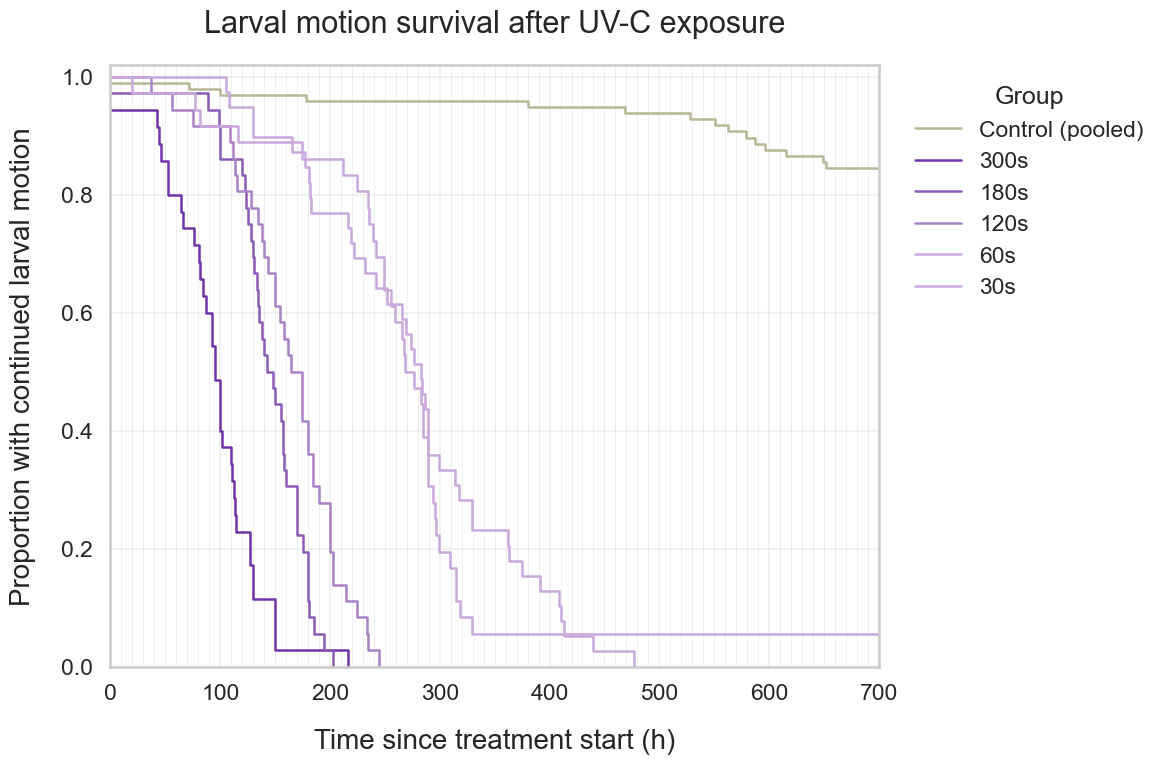

,group,n_total,n_events,n_censored,median_survival_h
0,Control (pooled),97,15,82,inf
1,UVC-6W-300s,35,35,0,95.5
2,UVC-6W-180s,36,36,0,142.8
3,UVC-6W-120s,36,36,0,164.9
4,UVC-6W-60s,36,34,2,268.5
5,UVC-6W-30s,39,39,0,282.5


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_kaplan_meier_motion_survival.png
Note: `UVC-6W-600s` was removed from the Kaplan-Meier plot because almost all larvae stopped motion right at the beginning of the footage (dt_motion_stop_h <= 0 h: 37/39, 94.9%).


In [34]:
# Kaplan-Meier survival curve (continued larval motion)

print('Figure caption: Kaplan-Meier curves of continued larval motion for pooled control plus plotted UVC groups. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), and censor marks are displayed. UVC-6W-600s is excluded from the plotted curves due to near-immediate stop behavior at footage start.')

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for Kaplan-Meier and log-rank analyses. Install with: pip install lifelines")

survival_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(ALL_GROUP_ORDER) & analysis_df["is_analyzed"],
    [
        "egg_uid",
        "analysis_group",
        "duration_survival_h",
        "is_event_survival",
        "dt_motion_stop_h",
        "t_motion_stop_h",
        "death_mode",
        "flags",
    ],
].copy()

survival_df = survival_df.rename(
    columns={
        "duration_survival_h": "duration_h",
        "is_event_survival": "event_observed",
    }
)
survival_df["event_observed"] = survival_df["event_observed"].astype(int)
survival_df["duration_h"] = survival_df["duration_h"].fillna(MAX_FOOTAGE_H).astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

KM_EXCLUDE_FROM_PLOT = {"UVC-6W-600s"}
groups_for_km_plot = [g for g in ALL_GROUP_ORDER if g not in KM_EXCLUDE_FROM_PLOT]
survival_df_plot = survival_df[survival_df["analysis_group"].isin(groups_for_km_plot)].copy()

uvc_treatment_colors = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
km_colors = {"Control (pooled)": "#b7b695"}
km_colors.update({g: uvc_treatment_colors[g] for g in groups_for_km_plot if g in uvc_treatment_colors})

fig, ax = plt.subplots(figsize=(12, 8))
km_rows = []

for group in groups_for_km_plot:
    g = survival_df_plot.loc[survival_df_plot["analysis_group"] == group].copy()
    if g.empty:
        continue

    kmf = KaplanMeierFitter()
    group_label = group.replace("UVC-6W-", "") if group.startswith("UVC-6W-") else group
    kmf.fit(
        durations=g["duration_h"],
        event_observed=g["event_observed"],
        label=group_label,
    )
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        color=km_colors.get(group, None),
        show_censors=True,
        censor_styles={"ms": 4, "marker": "|", "mew": 1.0},
        linewidth=1.8,
    )

    med = kmf.median_survival_time_
    km_rows.append(
        {
            "group": group,
            "n_total": int(len(g)),
            "n_events": int(g["event_observed"].sum()),
            "n_censored": int((g["event_observed"] == 0).sum()),
            "median_survival_h": float(med) if np.isfinite(med) else np.inf,
        }
    )

ax.set_xlim(0, MAX_FOOTAGE_H)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Time since treatment start (h)", labelpad=18, fontsize=20)
ax.set_ylabel("Proportion with continued larval motion", labelpad=18, fontsize=20)
ax.set_title("Larval motion survival after UV-C exposure", y=1.04, fontsize=22)
ax.grid(alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
ax.legend(title="Group", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out_png = PLOTS_DIR / "uvc_embryonated_kaplan_meier_motion_survival.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

km_summary_df = pd.DataFrame(km_rows)
display(km_summary_df)

km_summary_df.to_csv(TABLES_DIR / "uvc_embryonated_km_summary.csv", index=False)
survival_df.to_csv(TABLES_DIR / "uvc_embryonated_km_input_data.csv", index=False)
print(f"Saved: {out_png.resolve()}")

sub_600 = analysis_df.loc[
    (analysis_df["analysis_group"] == "UVC-6W-600s") & (analysis_df["is_analyzed"])
].copy()
n_total_600 = int(len(sub_600))
if n_total_600 > 0:
    n_stop_at_start_600 = int((sub_600["dt_motion_stop_h"].fillna(np.inf) <= 0).sum())
    pct_stop_at_start_600 = round(pct(n_stop_at_start_600, n_total_600), 1)
    print(
        "Note: `UVC-6W-600s` was removed from the Kaplan-Meier plot because almost all larvae "
        "stopped motion right at the beginning of the footage "
        f"(dt_motion_stop_h <= 0 h: {n_stop_at_start_600}/{n_total_600}, {pct_stop_at_start_600}%)."
    )
else:
    print("Note: `UVC-6W-600s` was removed from the Kaplan-Meier plot (no analyzed rows found).")




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Kaplan-Meier curves for continued larval motion over 0-700 h in pooled controls plus plotted UVC treatment groups. Event definition: observed in-window motion stop (`event_observed = 1`). Censoring definition: continued motion/no in-window stop (`event_observed = 0`), shown as tick marks. `UVC-6W-600s` is excluded from plotted curves due to near-immediate stop behavior at footage start; statistical comparisons are reported in Step 9C with Bonferroni-adjusted interpretation.


Figure caption: Normality diagnostics for `dt_motion_stop_h` across included UVC analysis groups. Shapiro-Wilk statistics are listed where n>=3, and Q-Q panels compare observed and theoretical normal quantiles by group. Groups with zero analyzed eggs are excluded from inferential testing, and low-n panels are explicitly marked.


,group,n_stopped_in_egg,shapiro_W,shapiro_p,normal_by_shapiro_p_gt_0_05,note
0,Control (pooled),6,0.729307,1.240298e-02,False,
1,UVC-6W-600s,39,0.235922,5.400801e-13,False,
2,UVC-6W-300s,35,0.963962,2.996098e-01,True,
3,UVC-6W-180s,35,0.975879,6.226783e-01,True,
4,UVC-6W-120s,36,0.966621,3.405573e-01,True,
5,UVC-6W-60s,33,0.786365,1.792553e-05,False,
6,UVC-6W-30s,37,0.978224,6.697694e-01,True,


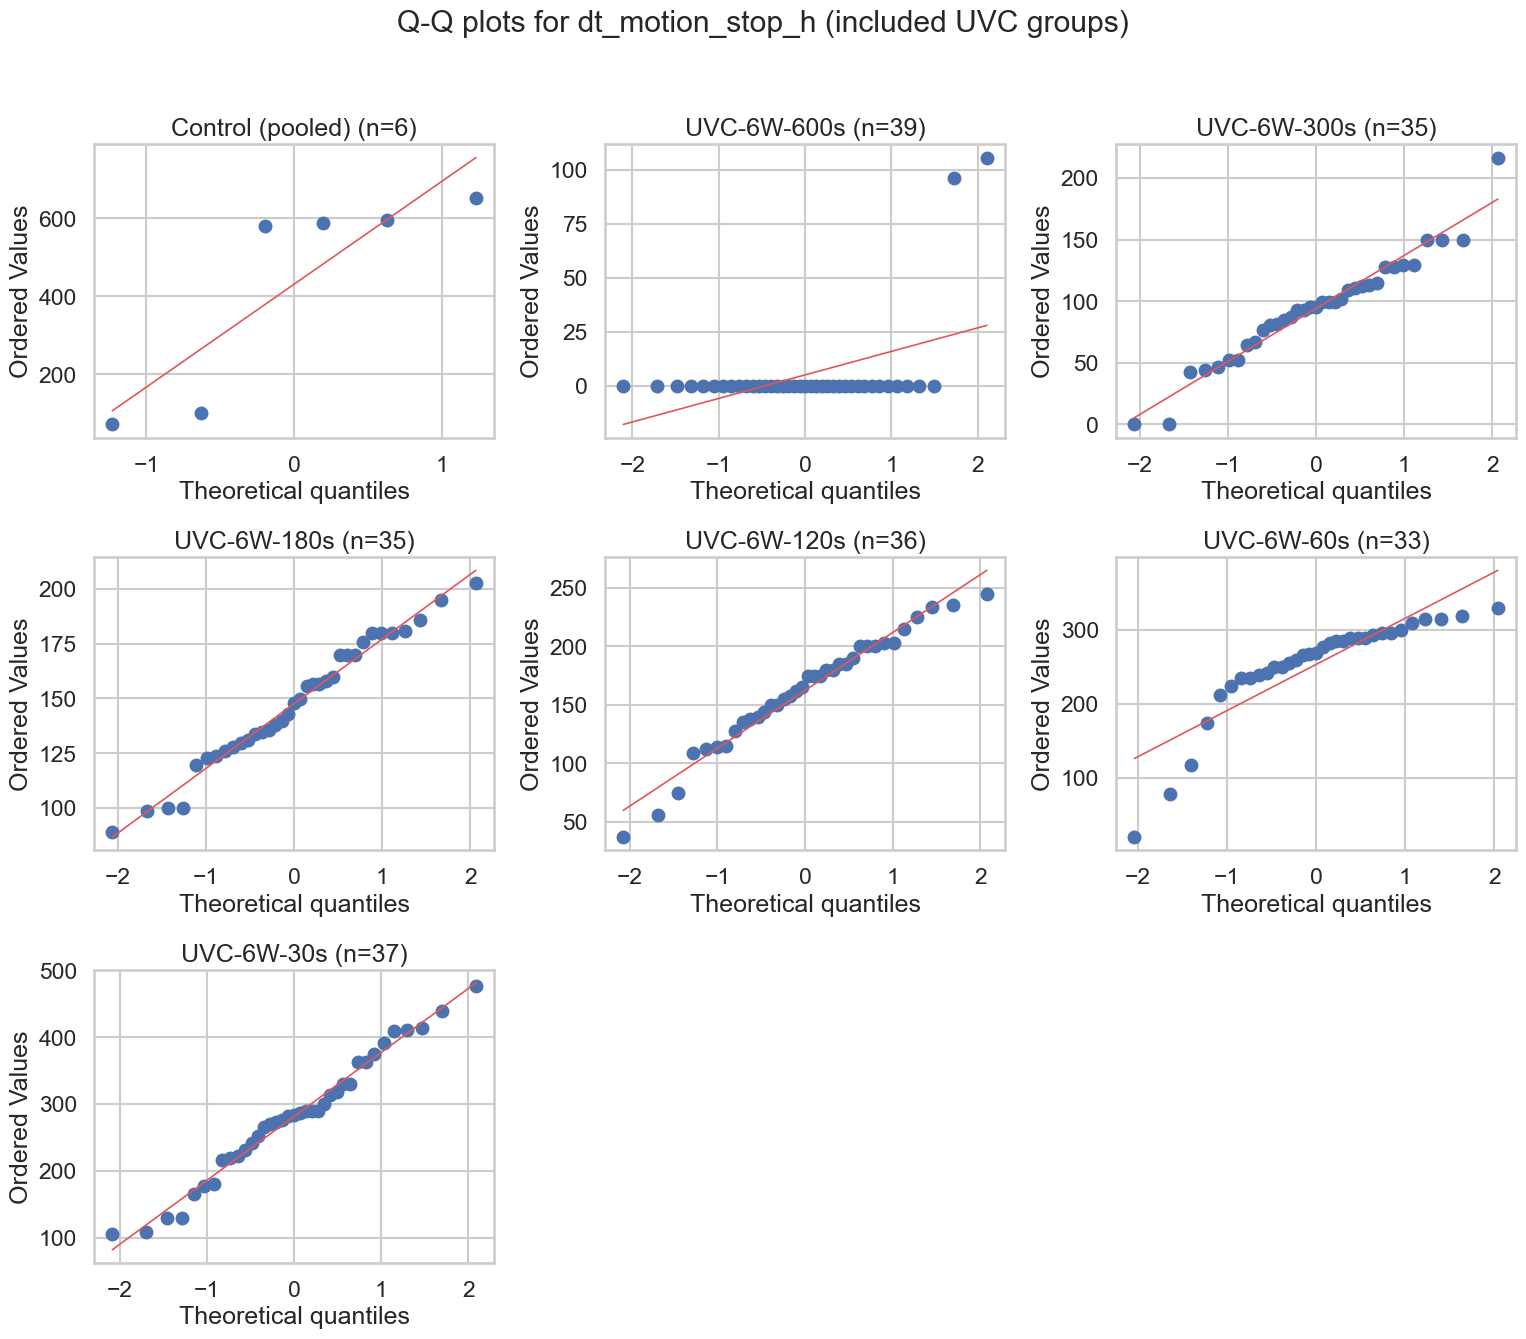

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_normality_qqplots.png
Selected comparison family: non_parametric
Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.


In [35]:
# Normality testing (Shapiro-Wilk) + Q-Q plots

print('Figure caption: Normality diagnostics for `dt_motion_stop_h` across included UVC analysis groups. Shapiro-Wilk statistics are listed where n>=3, and Q-Q panels compare observed and theoretical normal quantiles by group. Groups with zero analyzed eggs are excluded from inferential testing, and low-n panels are explicitly marked.')

group_n_analyzed = (
    analysis_df.loc[analysis_df["is_analyzed"]]
    .groupby("analysis_group", observed=False)
    .size()
    .reindex(ALL_GROUP_ORDER, fill_value=0)
)
STATS_GROUP_ORDER = [g for g in ALL_GROUP_ORDER if int(group_n_analyzed.get(g, 0)) > 0]

excluded_zero_n = [g for g in ALL_GROUP_ORDER if g not in STATS_GROUP_ORDER]
if excluded_zero_n:
    print("Note: Excluding groups with zero analyzed eggs from stats:", ", ".join(excluded_zero_n))

time_comp_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(STATS_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()

time_groups = {
    g: time_comp_df.loc[time_comp_df["analysis_group"] == g, "dt_motion_stop_h"].dropna().astype(float)
    for g in STATS_GROUP_ORDER
}

normality_rows = []
for group in STATS_GROUP_ORDER:
    vals = time_groups[group]
    n = int(len(vals))
    if n >= 3:
        sh_w, sh_p = stats.shapiro(vals)
    else:
        sh_w, sh_p = np.nan, np.nan

    normality_rows.append(
        {
            "group": group,
            "n_stopped_in_egg": n,
            "shapiro_W": float(sh_w) if pd.notna(sh_w) else np.nan,
            "shapiro_p": float(sh_p) if pd.notna(sh_p) else np.nan,
            "normal_by_shapiro_p_gt_0_05": bool(sh_p > 0.05) if pd.notna(sh_p) else np.nan,
            "note": "Shapiro requires n>=3" if n < 3 else "",
        }
    )

normality_df = pd.DataFrame(normality_rows)
display(normality_df)
normality_df.to_csv(TABLES_DIR / "uvc_embryonated_normality_shapiro.csv", index=False)

n_groups = len(STATS_GROUP_ORDER)
ncols = 3
nrows = int(np.ceil(n_groups / ncols)) if n_groups > 0 else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, group in zip(axes, STATS_GROUP_ORDER):
    vals = time_groups[group]
    n = len(vals)
    if n >= 2:
        stats.probplot(vals, dist="norm", plot=ax)
        ax.get_lines()[1].set_color("#e15759")
        ax.get_lines()[1].set_linewidth(1.2)
        ax.set_title(f"{group} (n={n})")
    elif n == 1:
        ax.scatter([0], vals.values, color="black", s=30)
        ax.set_title(f"{group} (n=1; Q-Q limited)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")
    else:
        ax.text(0.5, 0.5, "No in-egg stop data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{group} (n=0)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")

for ax in axes[len(STATS_GROUP_ORDER):]:
    ax.axis("off")

plt.suptitle("Q-Q plots for dt_motion_stop_h (included UVC groups)", y=1.02)
plt.tight_layout()
out_png = PLOTS_DIR / "uvc_embryonated_normality_qqplots.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

insufficient_n_any = bool((normality_df["n_stopped_in_egg"] < 3).any()) if len(normality_df) > 0 else True
failed_shapiro_any = bool((normality_df["shapiro_p"].dropna() <= 0.05).any()) if len(normality_df) > 0 else True

USE_PARAMETRIC = (not insufficient_n_any) and (not failed_shapiro_any)
TEST_FAMILY = "parametric" if USE_PARAMETRIC else "non_parametric"

print("Selected comparison family:", TEST_FAMILY)
if USE_PARAMETRIC:
    print("Reason: all included groups had n>=3 and Shapiro p>0.05.")
else:
    print("Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.")



In [36]:
# Group comparisons + survival curve comparisons

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for log-rank analyses. Install with: pip install lifelines")

from itertools import combinations

if "STATS_GROUP_ORDER" not in globals():
    group_n_analyzed = (
        analysis_df.loc[analysis_df["is_analyzed"]]
        .groupby("analysis_group", observed=False)
        .size()
        .reindex(ALL_GROUP_ORDER, fill_value=0)
    )
    STATS_GROUP_ORDER = [g for g in ALL_GROUP_ORDER if int(group_n_analyzed.get(g, 0)) > 0]

CONTROL_GROUP = "Control (pooled)"
STATS_GROUP_ORDER_TREATED = [g for g in STATS_GROUP_ORDER if g != CONTROL_GROUP]

ctrl_sub = analysis_df.loc[
    (analysis_df["analysis_group"] == CONTROL_GROUP) & (analysis_df["is_analyzed"])
].copy()
n_ctrl = int(len(ctrl_sub))
n_ctrl_still = int(ctrl_sub["is_continued_motion"].sum()) if n_ctrl > 0 else 0
pct_ctrl_still = round(pct(n_ctrl_still, n_ctrl), 1) if n_ctrl > 0 else np.nan
print(
    "Note: Comparisons vs pooled control are removed in this cell because control larvae are untreated "
    "and the majority remained moving through the footage "
    f"({n_ctrl_still}/{n_ctrl}, {pct_ctrl_still}%)."
)

pairwise_order = list(combinations(STATS_GROUP_ORDER_TREATED, 2))
N_PAIRWISE = len(pairwise_order)
ALPHA_REPORT = 0.05

print(f"Included treated UVC groups for inferential statistics ({len(STATS_GROUP_ORDER_TREATED)}): {', '.join(STATS_GROUP_ORDER_TREATED)}")
print(f"Pairwise comparisons: {N_PAIRWISE}; Bonferroni threshold = {ALPHA_REPORT/N_PAIRWISE:.5f}" if N_PAIRWISE > 0 else "No pairwise comparisons available.")

time_stats_rows = []
vals_all = [time_groups[g].to_numpy(dtype=float) for g in STATS_GROUP_ORDER_TREATED if len(time_groups[g]) > 0]

if USE_PARAMETRIC:
    overall_test_name = "One-way ANOVA"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.f_oneway(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Welch t-test"
else:
    overall_test_name = "Kruskal-Wallis H"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.kruskal(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Mann-Whitney U"

time_stats_rows.append(
    {
        "Comparison": "Overall (treated UVC groups)",
        "Statistical Test Used": overall_test_name,
        "Test Statistic": float(overall_stat) if pd.notna(overall_stat) else np.nan,
        "p_raw": float(overall_p) if pd.notna(overall_p) else np.nan,
        "p_bonf": np.nan,
        "sig": p_to_sig(float(overall_p)) if pd.notna(overall_p) else "NA",
    }
)

for a, b in pairwise_order:
    va = time_groups[a].to_numpy(dtype=float)
    vb = time_groups[b].to_numpy(dtype=float)

    if USE_PARAMETRIC:
        if len(va) >= 2 and len(vb) >= 2:
            st = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")
            stat_val, p_raw = float(st.statistic), float(st.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan
    else:
        if len(va) >= 1 and len(vb) >= 1:
            st = stats.mannwhitneyu(va, vb, alternative="two-sided")
            stat_val, p_raw = float(st.statistic), float(st.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    time_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Statistical Test Used": pair_test_name,
            "Test Statistic": stat_val,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "sig": p_to_sig(p_bonf),
            "significant_bonferroni": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
        }
    )

time_stats_df = pd.DataFrame(time_stats_rows)
display(time_stats_df)
time_stats_df.to_csv(TABLES_DIR / "uvc_embryonated_time_statistics_summary.csv", index=False)

time_posthoc_sig_df = time_stats_df.loc[
    (time_stats_df["Comparison"] != "Overall (treated UVC groups)")
    & (time_stats_df["significant_bonferroni"] == True)
].copy()

rows = []
for _, r in time_posthoc_sig_df.iterrows():
    g1_name, g2_name = r["Comparison"].split(" vs. ")

    g1 = time_groups[g1_name].to_numpy(dtype=float)
    g2 = time_groups[g2_name].to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "comparison": r["Comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_bonf": r["p_bonf"],
            "sig": r["sig"],
        }
    )

if rows:
    time_sig_diffs_df = pd.DataFrame(rows).sort_values(["comparison"]).reset_index(drop=True)
else:
    time_sig_diffs_df = pd.DataFrame(
        columns=[
            "comparison",
            "n_group1",
            "n_group2",
            "median_group1_h",
            "median_group2_h",
            "median_diff_h_(g2-g1)",
            "mean_group1_h",
            "mean_group2_h",
            "mean_diff_h_(g2-g1)",
            "sd_group1_h",
            "sd_group2_h",
            "sd_diff_indep_h",
            "p_bonf",
            "sig",
        ]
    )
display(time_sig_diffs_df)
time_sig_diffs_df.to_csv(TABLES_DIR / "uvc_embryonated_time_significant_differences.csv", index=False)


if "survival_df" not in globals():
    raise RuntimeError("Run Step 8 first to create survival_df before Step 9C.")

survival_df_stats = survival_df.loc[survival_df["analysis_group"].isin(STATS_GROUP_ORDER_TREATED)].copy()

if len(STATS_GROUP_ORDER_TREATED) >= 2:
    overall_lr = multivariate_logrank_test(
        event_durations=survival_df_stats["duration_h"],
        groups=survival_df_stats["analysis_group"],
        event_observed=survival_df_stats["event_observed"],
    )
    overall_chi2 = float(overall_lr.test_statistic)
    overall_p = float(overall_lr.p_value)
else:
    overall_chi2, overall_p = np.nan, np.nan

survival_stats_rows = [
    {
        "Comparison": "Overall (treated UVC curves)",
        "Log-rank chi2": overall_chi2,
        "p_raw": overall_p,
        "p_bonf": np.nan,
        "sig": p_to_sig(overall_p),
    }
]

for a, b in pairwise_order:
    ga = survival_df_stats.loc[survival_df_stats["analysis_group"] == a]
    gb = survival_df_stats.loc[survival_df_stats["analysis_group"] == b]

    if len(ga) > 0 and len(gb) > 0:
        lr = logrank_test(
            ga["duration_h"],
            gb["duration_h"],
            event_observed_A=ga["event_observed"],
            event_observed_B=gb["event_observed"],
        )
        chi2 = float(lr.test_statistic)
        p_raw = float(lr.p_value)
    else:
        chi2 = np.nan
        p_raw = np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    survival_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Log-rank chi2": chi2,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "sig": p_to_sig(p_bonf),
            "significant_bonferroni": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
        }
    )

survival_stats_df = pd.DataFrame(survival_stats_rows)
display(survival_stats_df)
survival_stats_df.to_csv(TABLES_DIR / "uvc_embryonated_survival_logrank_summary.csv", index=False)

survival_posthoc_sig_df = survival_stats_df.loc[
    (survival_stats_df["Comparison"] != "Overall (treated UVC curves)")
    & (survival_stats_df["significant_bonferroni"] == True)
].copy()
display(survival_posthoc_sig_df)
survival_posthoc_sig_df.to_csv(TABLES_DIR / "uvc_embryonated_survival_logrank_significant_pairs.csv", index=False)

print(
    "Significance coding in this cell: raw p-values are Bonferroni-adjusted for pairwise comparisons "
    f"using N={N_PAIRWISE}; significance threshold for adjusted p is {ALPHA_REPORT:.3f}."
)

method_meta_df = pd.DataFrame(
    [
        {
            "selected_test_family": TEST_FAMILY,
            "pairwise_alpha_report": ALPHA_REPORT,
            "pairwise_n_comparisons": N_PAIRWISE,
            "n_included_groups": len(STATS_GROUP_ORDER_TREATED),
            "control_removed_from_stats": True,
            "control_reason": "untreated and >80% still moving by end of footage",
            "excluded_zero_analyzed_groups": ";".join([g for g in ALL_GROUP_ORDER if g not in STATS_GROUP_ORDER]),
            "normality_decision_rule": "parametric only if all included groups n>=3 and Shapiro p>0.05",
        }
    ]
)
method_meta_df.to_csv(TABLES_DIR / "uvc_embryonated_stats_method_metadata.csv", index=False)



Note: Comparisons vs pooled control are removed in this cell because control larvae are untreated and the majority remained moving through the footage (82/97, 84.5%).
Included treated UVC groups for inferential statistics (6): UVC-6W-600s, UVC-6W-300s, UVC-6W-180s, UVC-6W-120s, UVC-6W-60s, UVC-6W-30s
Pairwise comparisons: 15; Bonferroni threshold = 0.00333


,Comparison,Statistical Test Used,Test Statistic,p_raw,p_bonf,sig,significant_bonferroni
0,Overall (treated UVC groups),Kruskal-Wallis H,162.671669,2.667270e-33,NaN,***,NaN
1,UVC-6W-600s vs. UVC-6W-300s,Mann-Whitney U,77.000000,1.340605e-12,2.010907e-11,***,True
2,UVC-6W-600s vs. UVC-6W-180s,Mann-Whitney U,5.000000,4.648831e-15,6.973246e-14,***,True
3,UVC-6W-600s vs. UVC-6W-120s,Mann-Whitney U,6.000000,3.745034e-15,5.617551e-14,***,True
4,UVC-6W-600s vs. UVC-6W-60s,Mann-Whitney U,4.000000,7.960645e-15,1.194097e-13,***,True
5,UVC-6W-600s vs. UVC-6W-30s,Mann-Whitney U,0.500000,1.704020e-15,2.556030e-14,***,True
6,UVC-6W-300s vs. UVC-6W-180s,Mann-Whitney U,157.000000,9.012082e-08,1.351812e-06,***,True
7,UVC-6W-300s vs. UVC-6W-120s,Mann-Whitney U,170.000000,1.250852e-07,1.876278e-06,***,True
8,UVC-6W-300s vs. UVC-6W-60s,Mann-Whitney U,68.000000,4.180871e-10,6.271306e-09,***,True
9,UVC-6W-300s vs. UVC-6W-30s,Mann-Whitney U,39.500000,7.590193e-12,1.138529e-10,***,True


,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_bonf,sig
0,UVC-6W-120s vs. UVC-6W-30s,36,37,169.9,283.5,113.6,162.344444,281.472973,119.128529,48.623007,93.308773,105.217507,1.613247e-06,***
1,UVC-6W-120s vs. UVC-6W-60s,36,33,169.9,268.5,98.6,162.344444,253.287879,90.943434,48.623007,68.487114,83.992152,3.848378e-07,***
2,UVC-6W-180s vs. UVC-6W-30s,35,37,147.8,283.5,135.7,147.600000,281.472973,133.872973,28.808495,93.308773,97.654782,1.276804e-07,***
3,UVC-6W-180s vs. UVC-6W-60s,35,33,147.8,268.5,120.7,147.600000,253.287879,105.687879,28.808495,68.487114,74.299490,1.389485e-07,***
4,UVC-6W-300s vs. UVC-6W-120s,35,36,95.5,169.9,74.4,94.157143,162.344444,68.187302,42.599843,48.623007,64.644748,1.876278e-06,***
5,UVC-6W-300s vs. UVC-6W-180s,35,35,95.5,147.8,52.3,94.157143,147.600000,53.442857,42.599843,28.808495,51.426414,1.351812e-06,***
6,UVC-6W-300s vs. UVC-6W-30s,35,37,95.5,283.5,188.0,94.157143,281.472973,187.315830,42.599843,93.308773,102.573260,1.138529e-10,***
7,UVC-6W-300s vs. UVC-6W-60s,35,33,95.5,268.5,173.0,94.157143,253.287879,159.130736,42.599843,68.487114,80.655015,6.271306e-09,***
8,UVC-6W-600s vs. UVC-6W-120s,39,36,0.0,169.9,169.9,5.169231,162.344444,157.175214,22.550145,48.623007,53.597629,5.617551e-14,***
9,UVC-6W-600s vs. UVC-6W-180s,39,35,0.0,147.8,147.8,5.169231,147.600000,142.430769,22.550145,28.808495,36.584675,6.973246e-14,***


,Comparison,Log-rank chi2,p_raw,p_bonf,sig,significant_bonferroni
0,Overall (treated UVC curves),332.701465,9.259889e-70,NaN,***,NaN
1,UVC-6W-600s vs. UVC-6W-300s,46.538045,8.985679e-12,1.347852e-10,***,True
2,UVC-6W-600s vs. UVC-6W-180s,72.881187,1.376945e-17,2.065417e-16,***,True
3,UVC-6W-600s vs. UVC-6W-120s,76.469493,2.236413e-18,3.354620e-17,***,True
4,UVC-6W-600s vs. UVC-6W-60s,76.469493,2.236413e-18,3.354620e-17,***,True
5,UVC-6W-600s vs. UVC-6W-30s,82.923102,8.530833e-20,1.279625e-18,***,True
6,UVC-6W-300s vs. UVC-6W-180s,20.223594,6.889792e-06,1.033469e-04,***,True
7,UVC-6W-300s vs. UVC-6W-120s,32.806456,1.018062e-08,1.527092e-07,***,True
8,UVC-6W-300s vs. UVC-6W-60s,60.647351,6.827189e-15,1.024078e-13,***,True
9,UVC-6W-300s vs. UVC-6W-30s,73.387419,1.065430e-17,1.598145e-16,***,True


,Comparison,Log-rank chi2,p_raw,p_bonf,sig,significant_bonferroni
1,UVC-6W-600s vs. UVC-6W-300s,46.538045,8.985679e-12,1.347852e-10,***,True
2,UVC-6W-600s vs. UVC-6W-180s,72.881187,1.376945e-17,2.065417e-16,***,True
3,UVC-6W-600s vs. UVC-6W-120s,76.469493,2.236413e-18,3.354620e-17,***,True
4,UVC-6W-600s vs. UVC-6W-60s,76.469493,2.236413e-18,3.354620e-17,***,True
5,UVC-6W-600s vs. UVC-6W-30s,82.923102,8.530833e-20,1.279625e-18,***,True
6,UVC-6W-300s vs. UVC-6W-180s,20.223594,6.889792e-06,1.033469e-04,***,True
7,UVC-6W-300s vs. UVC-6W-120s,32.806456,1.018062e-08,1.527092e-07,***,True
8,UVC-6W-300s vs. UVC-6W-60s,60.647351,6.827189e-15,1.024078e-13,***,True
9,UVC-6W-300s vs. UVC-6W-30s,73.387419,1.065430e-17,1.598145e-16,***,True
10,UVC-6W-180s vs. UVC-6W-120s,8.884825,2.875507e-03,4.313260e-02,*,True


Significance coding in this cell: raw p-values are Bonferroni-adjusted for pairwise comparisons using N=15; significance threshold for adjusted p is 0.050.


In [37]:
# UVC median/IQR vs nominal UV-C fluence (from fluence_tables) + correlation analysis

UVC_IRRADIANCE_NOMINAL_MW_CM2 = 2.11  # From fluence_tables.ipynb (nominal E8 estimate)
EXCLUDED_UVC_GROUPS = {
    "UVC-6W-600s": "Larvae were already motionless at recording start (immediate stop/death), so in-recording stop-time dynamics are not estimable.",
}
SELECTED_UVC_GROUPS = [g for g in TREATMENT_GROUP_ORDER if g not in EXCLUDED_UVC_GROUPS]
print(
    "Exclusion note: Removed UVC-6W-600s from correlation and plotting analyses because larvae were already motionless at recording start; this point does not represent in-recording time-to-motion-cessation dynamics."
)

selected_uvc_stop_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(SELECTED_UVC_GROUPS)
    & analysis_df["is_analyzed"]
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()


def parse_uvc_duration_s(group_label: str):
    m = re.search(r"(\d+)s$", str(group_label))
    if not m:
        return np.nan
    return float(m.group(1))


uvc_rows = []
for group in SELECTED_UVC_GROUPS:
    vals = selected_uvc_stop_df.loc[
        selected_uvc_stop_df["analysis_group"] == group,
        "dt_motion_stop_h",
    ].astype(float)

    exposure_s = parse_uvc_duration_s(group)
    nominal_fluence_mj_cm2 = (
        exposure_s * UVC_IRRADIANCE_NOMINAL_MW_CM2 if pd.notna(exposure_s) else np.nan
    )

    uvc_rows.append(
        {
            "treatment": group,
            "exposure_s": exposure_s,
            "nominal_irradiance_mW_cm2": UVC_IRRADIANCE_NOMINAL_MW_CM2,
            "nominal_fluence_mJ_cm2": round(float(nominal_fluence_mj_cm2), 1) if pd.notna(nominal_fluence_mj_cm2) else np.nan,
            "n_stopped_in_egg": int(vals.shape[0]),
            "median_dt_motion_stop_h": float(vals.median()) if vals.shape[0] > 0 else np.nan,
            "q1_dt_motion_stop_h": float(vals.quantile(0.25)) if vals.shape[0] > 0 else np.nan,
            "q3_dt_motion_stop_h": float(vals.quantile(0.75)) if vals.shape[0] > 0 else np.nan,
            "iqr_dt_motion_stop_h": float(vals.quantile(0.75) - vals.quantile(0.25)) if vals.shape[0] > 0 else np.nan,
        }
    )

uvc_fluence_summary_df = pd.DataFrame(uvc_rows)
display(uvc_fluence_summary_df)


def uvc_correlation_row(df: pd.DataFrame, metric_col: str) -> dict:
    sub = df[["nominal_fluence_mJ_cm2", metric_col]].dropna().copy()
    n = int(sub.shape[0])

    pearson_r = np.nan
    pearson_p = np.nan
    spearman_rho = np.nan
    spearman_p = np.nan

    if n >= 2:
        try:
            spearman_rho, spearman_p = stats.spearmanr(sub["nominal_fluence_mJ_cm2"], sub[metric_col])
        except Exception:
            pass

    if n >= 3:
        try:
            pearson_r, pearson_p = stats.pearsonr(sub["nominal_fluence_mJ_cm2"], sub[metric_col])
        except Exception:
            pass

    return {
        "metric": metric_col,
        "n_groups": n,
        "pearson_r": float(pearson_r) if pd.notna(pearson_r) else np.nan,
        "pearson_p": float(pearson_p) if pd.notna(pearson_p) else np.nan,
        "spearman_rho": float(spearman_rho) if pd.notna(spearman_rho) else np.nan,
        "spearman_p": float(spearman_p) if pd.notna(spearman_p) else np.nan,
    }


uvc_fluence_correlation_df = pd.DataFrame(
    [
        uvc_correlation_row(uvc_fluence_summary_df, "median_dt_motion_stop_h"),
        uvc_correlation_row(uvc_fluence_summary_df, "iqr_dt_motion_stop_h"),
    ]
)
display(uvc_fluence_correlation_df)

uvc_fluence_summary_df.to_csv(
    TABLES_DIR / "uvc_embryonated_fluence_median_iqr_summary.csv",
    index=False,
)
uvc_fluence_correlation_df.to_csv(
    TABLES_DIR / "uvc_embryonated_fluence_correlations.csv",
    index=False,
)
print(
    "Saved: "
    f"{(TABLES_DIR / 'uvc_embryonated_fluence_median_iqr_summary.csv').resolve()}\n"
    f"{(TABLES_DIR / 'uvc_embryonated_fluence_correlations.csv').resolve()}"
)

print(
    "Fluence note: Values use the nominal irradiance basis from fluence_tables.ipynb "
    "(2.11 mW/cm^2 at 8 cm). Reported rows for 30-300 s match that table; "
    "the 600 s nominal dose is 1266.0 mJ/cm^2 by the same formula (2.11 * 600), but this group is excluded from the correlation/plot due to immediate motion cessation at recording start."
)

print(
    "Correlation note (interpretation limits):\n"
    "- Spearman correlation is treated as the primary descriptive trend here (robust rank-based association).\n"
    "- This is a treatment-level median correlation (not egg-level modeling).\n"
    "- Correlations on grouped summaries do not fully model within-group variability, censoring, or unequal n."
)

alpha_sig = 0.05
median_corr_row = uvc_fluence_correlation_df.loc[
    uvc_fluence_correlation_df["metric"] == "median_dt_motion_stop_h"
]
if not median_corr_row.empty:
    rho_val = median_corr_row.iloc[0]["spearman_rho"]
    p_val = median_corr_row.iloc[0]["spearman_p"]
    if pd.notna(rho_val) and pd.notna(p_val):
        if p_val > alpha_sig:
            print(
                f"Significance note: Spearman rho={rho_val:.2f} but p={p_val:.3g} (> {alpha_sig}), "
                "so the median-based rank correlation is not statistically significant at alpha=0.05. "
                "Interpret as a trend (effect size) rather than confirmed significance."
            )
        else:
            print(
                f"Significance note: Spearman rho={rho_val:.2f}, p={p_val:.3g} (<= {alpha_sig}), "
                "indicating a statistically significant monotonic correlation at alpha=0.05."
            )


Exclusion note: Removed UVC-6W-600s from correlation and plotting analyses because larvae were already motionless at recording start; this point does not represent in-recording time-to-motion-cessation dynamics.


,treatment,exposure_s,nominal_irradiance_mW_cm2,nominal_fluence_mJ_cm2,n_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,UVC-6W-300s,300.0,2.11,633.0,35,95.5,71.50,114.0,42.50
1,UVC-6W-180s,180.0,2.11,379.8,35,147.8,128.80,169.8,41.00
2,UVC-6W-120s,120.0,2.11,253.2,36,169.9,137.15,199.9,62.75
3,UVC-6W-60s,60.0,2.11,126.6,33,268.5,239.50,293.5,54.00
4,UVC-6W-30s,30.0,2.11,63.3,37,283.5,221.50,329.5,108.00


,metric,n_groups,pearson_r,pearson_p,spearman_rho,spearman_p
0,median_dt_motion_stop_h,5,-0.952162,0.012470,-1.0,1.404265e-24
1,iqr_dt_motion_stop_h,5,-0.714164,0.175368,-0.8,1.040880e-01


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/tables/uvc_embryonated_fluence_median_iqr_summary.csv
/Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/tables/uvc_embryonated_fluence_correlations.csv
Fluence note: Values use the nominal irradiance basis from fluence_tables.ipynb (2.11 mW/cm^2 at 8 cm). Reported rows for 30-300 s match that table; the 600 s nominal dose is 1266.0 mJ/cm^2 by the same formula (2.11 * 600), but this group is excluded from the correlation/plot due to immediate motion cessation at recording start.
Correlation note (interpretation limits):
- Spearman correlation is treated as the primary descriptive trend here (robust rank-based association).
- This is a treatment-level median correlation (not egg-level modeling).
- Correlations on grouped summaries do not fully model within-group variability, censoring, or unequal n.
Significance note: Spearman rho=-1.00, p=1.4e-24 (<= 0.05), indicating a statistically signi

Plot note: UVC-6W-600s is excluded because larvae were already motionless at recording start (immediate stop/death), so it is not included in the fluence-response correlation plot.


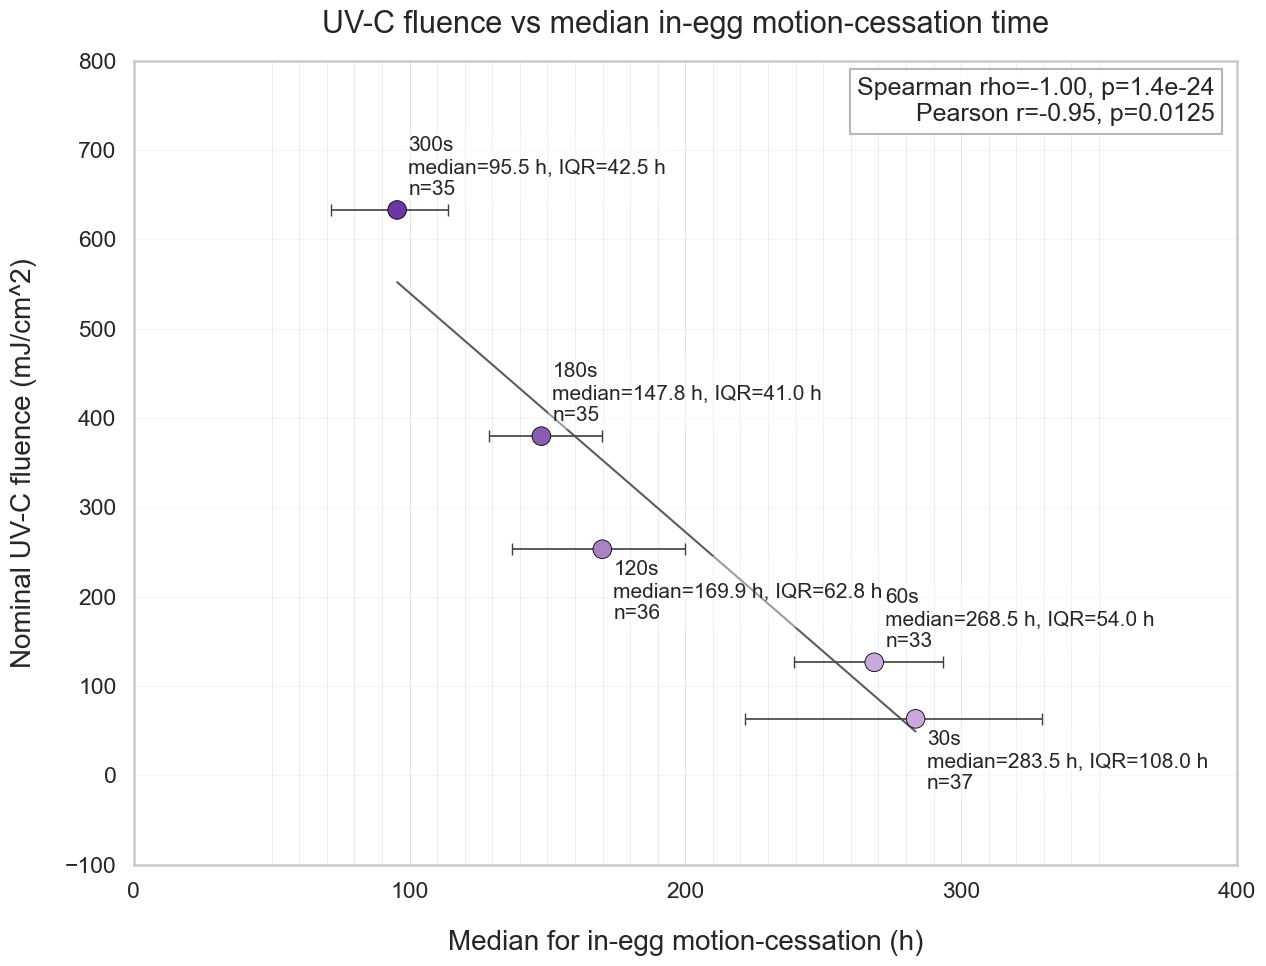

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/embryonated/plots/uvc_embryonated_fluence_median_iqr_stoptime_correlation.png
Figure caption: Relationship between nominal UV-C fluence (mJ/cm^2) and median in-egg motion-cessation time (h) for selected UVC treatments. The UVC-6W-600s group was excluded because larvae were already motionless at recording start, so in-recording stop-time dynamics were not estimable for that condition. Each point is one treatment-level summary; horizontal whiskers show the interquartile range (Q1-Q3) around the median. Point labels report treatment, median, IQR, and n eggs with observed in-egg motion cessation. The gray line is an unweighted linear fit across treatment-level points and is shown as a descriptive trend only. Correlation summary: Spearman rho=-1.00 (p=1.4e-24); Pearson r=-0.95 (p=0.0125); n_groups=5. Interpretation note: this is a group-level analysis with a small number of groups, so p-values and confidence in significance s

In [38]:
# Plot UVC median stop-time results vs nominal UV-C fluence

if "uvc_fluence_summary_df" not in globals() or uvc_fluence_summary_df.empty:
    raise RuntimeError("Run Step 11 first to create `uvc_fluence_summary_df` and `uvc_fluence_correlation_df`.")

if "EXCLUDED_UVC_GROUPS" in globals() and "UVC-6W-600s" in EXCLUDED_UVC_GROUPS:
    print(
        "Plot note: UVC-6W-600s is excluded because larvae were already motionless at recording start (immediate stop/death), so it is not included in the fluence-response correlation plot."
    )

plot_df = (
    uvc_fluence_summary_df
    .dropna(subset=["nominal_fluence_mJ_cm2", "median_dt_motion_stop_h", "q1_dt_motion_stop_h", "q3_dt_motion_stop_h"])
    .copy()
    .sort_values("nominal_fluence_mJ_cm2")
)
plot_df["treatment_short"] = plot_df["treatment"].str.replace("UVC-6W-", "", regex=False)

if plot_df.empty:
    raise RuntimeError("No data available for plotting UVC fluence correlation results.")

uvc_palette = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
palette_map = {
    row["treatment_short"]: uvc_palette.get(row["treatment"], "#8B5CB5")
    for _, row in plot_df.iterrows()
}

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

xerr_iqr = np.vstack([
    plot_df["median_dt_motion_stop_h"] - plot_df["q1_dt_motion_stop_h"],
    plot_df["q3_dt_motion_stop_h"] - plot_df["median_dt_motion_stop_h"],
])
ax.errorbar(
    plot_df["median_dt_motion_stop_h"],
    plot_df["nominal_fluence_mJ_cm2"],
    xerr=xerr_iqr,
    fmt="none",
    ecolor="#3f3f3f",
    elinewidth=1.2,
    capsize=4,
    zorder=1,
)

if plot_df.shape[0] >= 2:
    sns.regplot(
        data=plot_df,
        x="median_dt_motion_stop_h",
        y="nominal_fluence_mJ_cm2",
        scatter=False,
        ci=None,
        color="#4a4a4a",
        line_kws={"linewidth": 1.5, "alpha": 0.9},
        ax=ax,
    )

sns.scatterplot(
    data=plot_df,
    x="median_dt_motion_stop_h",
    y="nominal_fluence_mJ_cm2",
    hue="treatment_short",
    palette=palette_map,
    s=180,
    edgecolor="black",
    linewidth=0.6,
    legend=False,
    ax=ax,
    zorder=3,
)

cur_bottom, cur_top = ax.get_ylim()
y_pad_top = max((cur_top - cur_bottom) * 0.18, 0.01)
y_pad_bottom = max((cur_top - cur_bottom) * 0.12, 5.0)
ax.set_ylim(cur_bottom - y_pad_bottom, cur_top + y_pad_top)

x_min, x_max = ax.get_xlim()
x_min = float(np.floor(x_min))
x_max = float(np.ceil(x_max))
x_start = 10 * np.floor(x_min / 10.0)
x_end = 10 * np.ceil(x_max / 10.0)
if x_end <= x_start:
    x_end = x_start + 10
major_start = 100 * np.floor(x_min / 100.0)
major_end = 100 * np.ceil(x_max / 100.0)
if major_end <= major_start:
    major_end = major_start + 100
ax.set_xticks(np.arange(major_start, major_end + 100, 100))
ax.set_xticks(np.arange(x_start, x_end + 10, 10), minor=True)

for _, row in plot_df.iterrows():
    label = (
        f"{row['treatment_short']}\n"
        f"median={row['median_dt_motion_stop_h']:.1f} h, IQR={row['iqr_dt_motion_stop_h']:.1f} h\n"
        f"n={int(row['n_stopped_in_egg'])}"
    )
    xy_offset = (8, 8)
    va = "bottom"
    if row["treatment"] in {"UVC-6W-120s", "UVC-6W-30s"}:
        xy_offset = (8, -8)
        va = "top"
    ax.annotate(
        label,
        (row["median_dt_motion_stop_h"], row["nominal_fluence_mJ_cm2"]),
        xytext=xy_offset,
        textcoords="offset points",
        fontsize=15,
        ha="left",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2", alpha=0.4),
    )

corr_median = uvc_fluence_correlation_df.loc[
    uvc_fluence_correlation_df["metric"] == "median_dt_motion_stop_h"
]
if not corr_median.empty:
    cm = corr_median.iloc[0]
    txt = (
        f"Spearman rho={cm['spearman_rho']:.2f}, p={cm['spearman_p']:.3g}\n"
        f"Pearson r={cm['pearson_r']:.2f}, p={cm['pearson_p']:.3g}"
    )
    ax.text(
        0.98,
        0.98,
        txt,
        transform=ax.transAxes,
        fontsize=18,
        va="top",
        ha="right",
        bbox=dict(facecolor="white", edgecolor="#b0b0b0", boxstyle="square,pad=0.3", alpha=0.9),
    )

ax.set_title("UV-C fluence vs median in-egg motion-cessation time", fontsize=22, pad=20)
ax.set_xlabel("Median for in-egg motion-cessation (h)", fontsize=20, labelpad=20)
ax.set_ylabel("Nominal UV-C fluence (mJ/cm^2)", fontsize=20, labelpad=20)
y_min_grid, y_max_grid = ax.get_ylim()
y_start = 100 * np.floor(y_min_grid / 100.0)
y_end = 100 * np.ceil(y_max_grid / 100.0)
if y_end <= y_start:
    y_end = y_start + 100
ax.set_yticks(np.arange(y_start, y_end + 100, 100))
ax.grid(False)
ax.grid(axis="x", which="minor", color="#e3e7ee", linewidth=0.6, alpha=0.9)
ax.grid(axis="x", which="major", color="#d7dde8", linewidth=0.75, alpha=0.8)
ax.grid(axis="y", which="major", color="#e7ecf3", linewidth=0.55, alpha=0.75)

plt.tight_layout()

out_png = PLOTS_DIR / "uvc_embryonated_fluence_median_iqr_stoptime_correlation.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

if not corr_median.empty:
    corr_caption = (
        f"Spearman rho={cm['spearman_rho']:.2f} (p={cm['spearman_p']:.3g}); "
        f"Pearson r={cm['pearson_r']:.2f} (p={cm['pearson_p']:.3g}); "
        f"n_groups={int(cm['n_groups'])}"
    )
else:
    corr_caption = "Correlation metrics unavailable (insufficient non-missing points)."

figure_caption = (
    "Figure caption: Relationship between nominal UV-C fluence (mJ/cm^2) and median in-egg "
    "motion-cessation time (h) for selected UVC treatments. "
    "The UVC-6W-600s group was excluded because larvae were already motionless at recording start, "
    "so in-recording stop-time dynamics were not estimable for that condition. "
    "Each point is one treatment-level summary; horizontal whiskers show the interquartile range "
    "(Q1-Q3) around the median. Point labels report treatment, median, IQR, and n eggs with "
    "observed in-egg motion cessation. The gray line is an unweighted linear fit across "
    "treatment-level points and is shown as a descriptive trend only. "
    f"Correlation summary: {corr_caption}. "
    "Interpretation note: this is a group-level analysis with a small number of groups, so "
    "p-values and confidence in significance should be interpreted cautiously."
)
print(figure_caption)

if not corr_median.empty:
    rho_val = cm["spearman_rho"]
    p_val = cm["spearman_p"]
    n_groups = int(cm["n_groups"]) if pd.notna(cm["n_groups"]) else np.nan
    if pd.notna(rho_val) and pd.notna(p_val):
        if rho_val > 0:
            direction = "positive"
        elif rho_val < 0:
            direction = "negative"
        else:
            direction = "no clear"

        abs_rho = abs(float(rho_val))
        if abs_rho >= 0.8:
            strength = "strong"
        elif abs_rho >= 0.5:
            strength = "moderate"
        elif abs_rho >= 0.3:
            strength = "weak-to-moderate"
        else:
            strength = "weak"

        if p_val <= 0.05:
            significance_note = "statistically significant"
        else:
            significance_note = "not statistically significant; interpret as a tendency/trend"

        print(
            "Relation note: "
            f"Spearman analysis indicates a {strength} {direction} effect "
            f"(rho={rho_val:.2f}, p={p_val:.3g}, n_groups={n_groups}); "
            f"this relation is {significance_note}."
        )
    else:
        print("Relation note: Effect direction/strength unavailable because Spearman outputs are missing.")
else:
    print("Relation note: Effect and significance unavailable because no median-correlation row was found.")
